Sat May 30th:
Initial implementation of an MLP layer, and ridge regression, as well as weights. Found that accuracy was slightly increased with MLP and ridge regression, with regular unweighted MLP being the heighest.

In [1]:
import numpy as np
import pandas as pd
import torch
import esm   
# from Bio import SeqIO
import torch
# import gc
from sklearn.manifold import TSNE
from sklearn import metrics
import matplotlib.pyplot as plt
import pickle

from sklearn.decomposition import PCA


# #for google colab only
# !pip install fair-esm

In [3]:
# load the dataframes
train_df_mean = pd.read_csv("../processed_data/df_train_loc_mean.csv")
train_df_max = pd.read_csv("../processed_data/df_train_loc_max.csv")

In [4]:
locations = ['Membrane', 'Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane',
             'Mitochondrion', 'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole',
             'Golgi apparatus', 'Peroxisome']

# mean
y_train_df_mean = train_df_mean[locations]
balancing_weights = y_train_df_mean.shape[0]/y_train_df_mean.sum()
x_train_df_mean = train_df_mean[[c for c in train_df_mean.columns if c.startswith('emb_')]]

# max
y_train_df_max = train_df_max[locations]
balancing_weights = y_train_df_max.shape[0]/y_train_df_max.sum()
x_train_df_max = train_df_max[[c for c in train_df_max.columns if c.startswith('emb_')]]

In [5]:
# generate train/dev split
from sklearn.model_selection import train_test_split

# for mean
x_train_mean, x_dev_mean, y_train_mean, y_dev_mean = train_test_split(x_train_df_mean, y_train_df_mean, test_size=0.2, random_state=42)

# for max
x_train_max, x_dev_max, y_train_max, y_dev_max = train_test_split(x_train_df_max, y_train_df_max, test_size=0.2, random_state=42)

In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# load the batches and make the model for mean
x_train_mean_tensor = torch.tensor(x_train_mean.values, dtype=torch.float32)
y_train_mean_tensor = torch.tensor(y_train_mean.values, dtype=torch.float32)
train_dataset_mean = TensorDataset(x_train_mean_tensor, y_train_mean_tensor)
train_loader_mean = DataLoader(train_dataset_mean, batch_size=64, shuffle=True)

# load the batches and make the model for max
x_train_max_tensor = torch.tensor(x_train_max.values, dtype=torch.float32)
y_train_max_tensor = torch.tensor(y_train_max.values, dtype=torch.float32)
train_dataset_max = TensorDataset(x_train_max_tensor, y_train_max_tensor)
train_loader_max = DataLoader(train_dataset_max, batch_size=64, shuffle=True)

# make dev tensors
x_dev_mean_tensor = torch.tensor(x_dev_mean.values, dtype=torch.float32)
y_dev_mean_tensor = torch.tensor(y_dev_mean.values, dtype=torch.float32)
x_dev_max_tensor = torch.tensor(x_dev_max.values, dtype=torch.float32)
y_dev_max_tensor = torch.tensor(y_dev_max.values, dtype=torch.float32)

In [7]:
# make the model - multilayer perceptatron - two hidden layers
class MLP(nn.Module):
    
    def __init__(self, input_size, num_logits):
        # call to the __init__ function of the super class
        super().__init__()

        # Bookkeeping: Sacing the initialization parameters
        self.input_size = input_size
        self.num_logits = num_logits

        # Defining the model
        self.model = nn.Sequential(
            nn.Linear(self.input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.num_logits),
        )

    def forward(self, x):
        logits = self.model(x)
        return logits
    

In [8]:
import torch.optim as optim
from sklearn.metrics import (matthews_corrcoef, f1_score,
                             hamming_loss, jaccard_score)

# train the model
def train_model(model, loader, criterion, optimizer, x_dev_tensor, y_dev_tensor, num_epochs):
    # initialize the lists
    print("Training started!")
    train_loss_lst = []
    dev_loss_lst = []
    # go through the training epochs
    for epoch in range(num_epochs):
        train_loss = 0.0
        # configure the model for training
        model.train()
        for batch in loader:
            inputs, labels = batch
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)
        
        # evaluate the dev set
        model.eval()
        with torch.no_grad():
            logits_dev = model(x_dev_tensor)
            loss_dev = criterion(logits_dev, y_dev_tensor)
            dev_loss_lst.append(loss_dev.item())
        # print the progress
        #if epoch % 10 == 0 or epoch == num_epochs - 1:
            #print(f"Epoch {epoch+1}/{num_epochs}, Train Loss {train_loss:.4f}, Dev Loss {loss_dev.item():.4f}")
    print("Training Complete!")
    return train_loss_lst, dev_loss_lst

def plot_losses(train_loss_lst, dev_loss_lst, n_epochs, experiment_title):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_epochs + 1), train_loss_lst, label='train')
    plt.plot(range(1, n_epochs + 1), dev_loss_lst,   label='dev')
    plt.xlabel('Epoch')
    plt.ylabel('Avg BCE Loss')
    plt.title(f"Training vs. Dev Loss for {experiment_title}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return

def run_experiment(x_train, y_train, train_loader, x_dev, y_dev, criterion, experiment_title, num_epochs):
    model = LogisticRegression(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst, dev_loss_lst = train_model(model, train_loader, criterion, optimizer, x_dev, y_dev, num_epochs)

    # graph the losses
    #plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

# all thresholds set to 0.5
def compute_accuracy(model, X_dev, Y_dev, locations):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_dev))
        preds = (probs > 0.5).float()

    y_np = Y_dev.numpy().astype(int)
    p_np = preds.numpy().astype(int)

    # overall metrics (adapted from deeploc2 calculate_sl_metrics_fold)
    acc_exact = (np.all(p_np == y_np, axis=1)).mean()          # all 11 labels correct
    jaccard = jaccard_score(y_np, p_np, average='samples')   # intersection/union per protein
    micro_f1 = f1_score(y_np, p_np, average='micro', zero_division=0)
    macro_f1 = f1_score(y_np, p_np, average='macro', zero_division=0)

    model_accs = [acc_exact, jaccard, micro_f1, macro_f1]
    
    #print(f"Exact-match accuracy : {acc_exact:.4f}")
    #print(f"Jaccard (samples)    : {jaccard:.4f}")
    #print(f"Micro F1             : {micro_f1:.4f}")
    #print(f"Macro F1             : {macro_f1:.4f}")

    # per-class accuracy & MCC
    #print("Per-class metrics:")
    #print(f"{'Location':<25} {'Accuracy':>10} {'MCC':>10}")
    #print("-" * 47)
    class_mccs = []
    for i, loc in enumerate(locations):
        class_acc = (p_np[:, i] == y_np[:, i]).mean()
        class_mcc = matthews_corrcoef(y_np[:, i], p_np[:, i])
        class_mccs.append(class_mcc)
        #print(f"{loc:<25} {class_acc:>10.4f} {class_mcc:>10.4f}")
    return model_accs, class_mccs


Epoch 1/100, Train Loss: 0.3517, Dev Loss: 0.2697
Epoch 11/100, Train Loss: 0.1662, Dev Loss: 0.1829
Epoch 21/100, Train Loss: 0.1408, Dev Loss: 0.1753
Epoch 31/100, Train Loss: 0.1217, Dev Loss: 0.1791
Epoch 41/100, Train Loss: 0.1030, Dev Loss: 0.1817
Epoch 51/100, Train Loss: 0.0881, Dev Loss: 0.1951
Epoch 61/100, Train Loss: 0.0733, Dev Loss: 0.2185
Epoch 71/100, Train Loss: 0.0612, Dev Loss: 0.2354
Epoch 81/100, Train Loss: 0.0520, Dev Loss: 0.2568
Epoch 91/100, Train Loss: 0.0425, Dev Loss: 0.2853
Epoch 100/100, Train Loss: 0.0378, Dev Loss: 0.3087
Training complete.


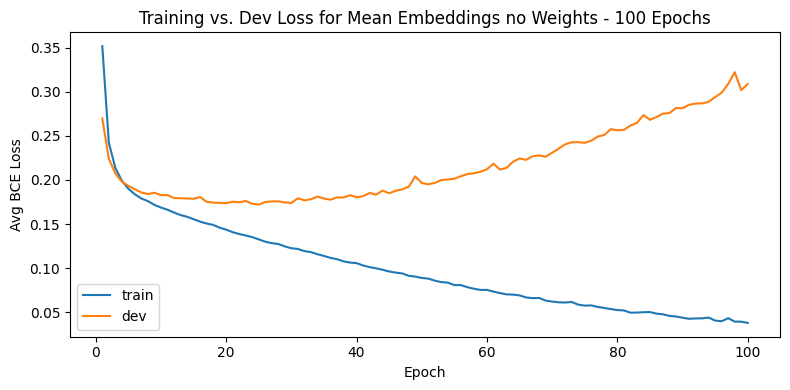

Exact-match accuracy : 0.5414
Hamming accuracy     : 0.9317
Jaccard (samples)    : 0.7054
Micro F1             : 0.7550
Macro F1             : 0.6908

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8878     0.7267
Cytoplasm                     0.8078     0.5846
Nucleus                       0.8571     0.6814
Extracellular                 0.9751     0.8861
Cell membrane                 0.9281     0.6876
Mitochondrion                 0.9588     0.7166
Plastid                       0.9923     0.8990
Endoplasmic reticulum         0.9353     0.5305
Lysosome/Vacuole              0.9543     0.4695
Golgi apparatus               0.9579     0.5331
Peroxisome                    0.9946     0.4057


In [12]:
# experiment 1: control with no reweighting on mean - 100 epochs
criterion_1 = nn.BCEWithLogitsLoss()
reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/100, Train Loss: 0.3631, Dev Loss: 0.3471
Epoch 11/100, Train Loss: 0.2477, Dev Loss: 0.2481
Epoch 21/100, Train Loss: 0.2182, Dev Loss: 0.2295
Epoch 31/100, Train Loss: 0.2032, Dev Loss: 0.2158
Epoch 41/100, Train Loss: 0.1906, Dev Loss: 0.2154
Epoch 51/100, Train Loss: 0.1829, Dev Loss: 0.2143
Epoch 61/100, Train Loss: 0.1756, Dev Loss: 0.2146
Epoch 71/100, Train Loss: 0.1702, Dev Loss: 0.2038
Epoch 81/100, Train Loss: 0.1631, Dev Loss: 0.2399
Epoch 91/100, Train Loss: 0.1561, Dev Loss: 0.2071
Epoch 100/100, Train Loss: 0.1547, Dev Loss: 0.2014
Training complete.


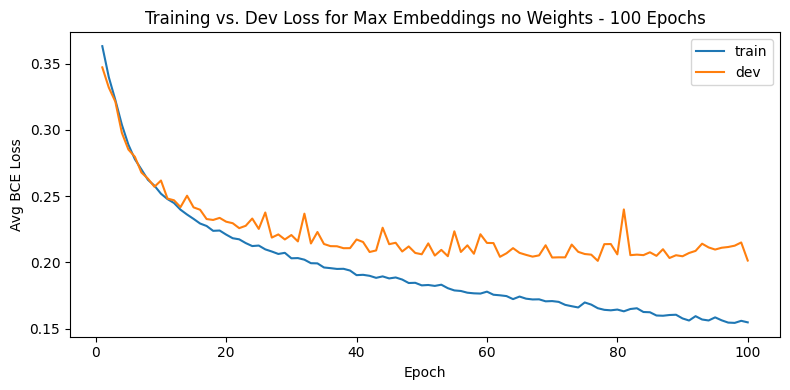

Exact-match accuracy : 0.4722
Hamming accuracy     : 0.9203
Jaccard (samples)    : 0.6351
Micro F1             : 0.7034
Macro F1             : 0.5767

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8602     0.6584
Cytoplasm                     0.7820     0.5179
Nucleus                       0.8213     0.6122
Extracellular                 0.9688     0.8510
Cell membrane                 0.9181     0.6468
Mitochondrion                 0.9552     0.6781
Plastid                       0.9869     0.8091
Endoplasmic reticulum         0.9263     0.4669
Lysosome/Vacuole              0.9489     0.0000
Golgi apparatus               0.9611     0.4708
Peroxisome                    0.9946     0.2026


In [9]:
# experiment 2: no reweighting on max - 100 epochs
criterion_2 = nn.BCEWithLogitsLoss()
reg_model_max = run_experiment(x_train_max_tensor, y_train_max_tensor, train_loader_max, x_dev_max_tensor, y_dev_max_tensor, criterion_2, experiment_title="Max Embeddings no Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reg_model_max, x_dev_max_tensor, y_dev_max_tensor, locations)

Epoch 1/100, Train Loss: 4.3380, Dev Loss: 2.9413
Epoch 11/100, Train Loss: 1.7514, Dev Loss: 1.7992
Epoch 21/100, Train Loss: 1.4575, Dev Loss: 1.6645
Epoch 31/100, Train Loss: 1.2904, Dev Loss: 1.6196
Epoch 41/100, Train Loss: 1.1619, Dev Loss: 1.6002
Epoch 51/100, Train Loss: 1.0613, Dev Loss: 1.6057
Epoch 61/100, Train Loss: 0.9771, Dev Loss: 1.6061
Epoch 71/100, Train Loss: 0.9120, Dev Loss: 1.6604
Epoch 81/100, Train Loss: 0.8489, Dev Loss: 1.6843
Epoch 91/100, Train Loss: 0.8032, Dev Loss: 1.7477
Epoch 100/100, Train Loss: 0.7625, Dev Loss: 1.7939
Training complete.


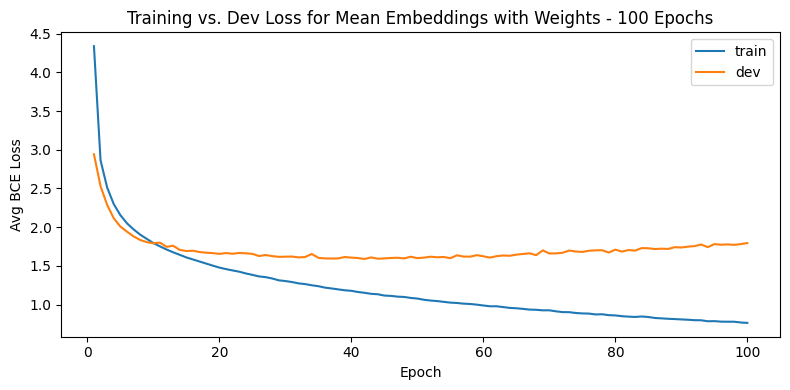

Exact-match accuracy : 0.5310
Hamming accuracy     : 0.9326
Jaccard (samples)    : 0.7014
Micro F1             : 0.7574
Macro F1             : 0.6940

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8883     0.7274
Cytoplasm                     0.8223     0.6198
Nucleus                       0.8417     0.6489
Extracellular                 0.9756     0.8866
Cell membrane                 0.9218     0.6735
Mitochondrion                 0.9584     0.7108
Plastid                       0.9928     0.8993
Endoplasmic reticulum         0.9439     0.5692
Lysosome/Vacuole              0.9557     0.4629
Golgi apparatus               0.9643     0.5241
Peroxisome                    0.9941     0.4774


In [10]:
# experiment 3: reweighting on mean - 100 epochs
criterion_3 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_3,  experiment_title="Mean Embeddings with Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/100, Train Loss: 3.8629, Dev Loss: 3.2978
Epoch 11/100, Train Loss: 2.7406, Dev Loss: 2.5910
Epoch 21/100, Train Loss: 2.2566, Dev Loss: 2.1931
Epoch 31/100, Train Loss: 2.0409, Dev Loss: 2.0823
Epoch 41/100, Train Loss: 1.8734, Dev Loss: 2.0254
Epoch 51/100, Train Loss: 1.7172, Dev Loss: 1.9640
Epoch 61/100, Train Loss: 1.5656, Dev Loss: 2.1634
Epoch 71/100, Train Loss: 1.4704, Dev Loss: 1.8649
Epoch 81/100, Train Loss: 1.4252, Dev Loss: 1.8543
Epoch 91/100, Train Loss: 1.3512, Dev Loss: 1.9764
Epoch 100/100, Train Loss: 1.2791, Dev Loss: 1.9402
Training complete.


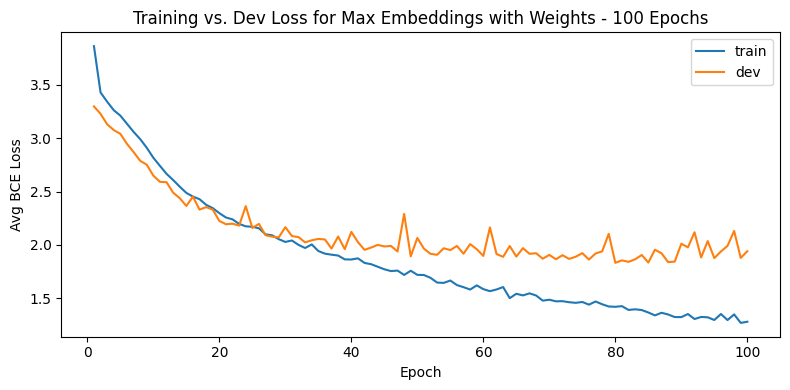

Exact-match accuracy : 0.4310
Hamming accuracy     : 0.9167
Jaccard (samples)    : 0.6083
Micro F1             : 0.6912
Macro F1             : 0.5790

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8589     0.6483
Cytoplasm                     0.7653     0.5011
Nucleus                       0.8042     0.5828
Extracellular                 0.9638     0.8205
Cell membrane                 0.9154     0.6173
Mitochondrion                 0.9539     0.6610
Plastid                       0.9891     0.8480
Endoplasmic reticulum         0.9322     0.4916
Lysosome/Vacuole              0.9507     0.2532
Golgi apparatus               0.9557     0.2938
Peroxisome                    0.9950     0.3317


In [11]:
# experiment 4: reweighting on max - 100 epochs
criterion_4 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
reweighting_model_max = run_experiment(x_train_max_tensor, y_train_max_tensor, train_loader_max, x_dev_max_tensor, y_dev_max_tensor, criterion_4, experiment_title="Max Embeddings with Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reweighting_model_max, x_dev_max_tensor, y_dev_max_tensor, locations)

Epoch 1/200, Train Loss: 0.3636, Dev Loss: 0.2871
Epoch 11/200, Train Loss: 0.1812, Dev Loss: 0.1901
Epoch 21/200, Train Loss: 0.1640, Dev Loss: 0.1812
Epoch 31/200, Train Loss: 0.1516, Dev Loss: 0.1782
Epoch 41/200, Train Loss: 0.1425, Dev Loss: 0.1768
Epoch 51/200, Train Loss: 0.1342, Dev Loss: 0.1758
Epoch 61/200, Train Loss: 0.1274, Dev Loss: 0.1762
Epoch 71/200, Train Loss: 0.1214, Dev Loss: 0.1772
Epoch 81/200, Train Loss: 0.1160, Dev Loss: 0.1810
Epoch 91/200, Train Loss: 0.1110, Dev Loss: 0.1820
Epoch 101/200, Train Loss: 0.1061, Dev Loss: 0.1837
Epoch 111/200, Train Loss: 0.1021, Dev Loss: 0.1881
Epoch 121/200, Train Loss: 0.0980, Dev Loss: 0.1909
Epoch 131/200, Train Loss: 0.0943, Dev Loss: 0.1929
Epoch 141/200, Train Loss: 0.0908, Dev Loss: 0.1975
Epoch 151/200, Train Loss: 0.0880, Dev Loss: 0.2033
Epoch 161/200, Train Loss: 0.0841, Dev Loss: 0.2043
Epoch 171/200, Train Loss: 0.0812, Dev Loss: 0.2088
Epoch 181/200, Train Loss: 0.0782, Dev Loss: 0.2112
Epoch 191/200, Train Lo

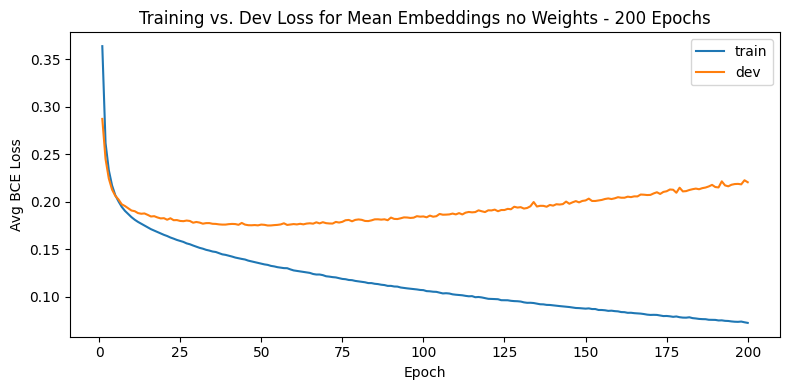

Exact-match accuracy : 0.5228
Hamming accuracy     : 0.9307
Jaccard (samples)    : 0.6963
Micro F1             : 0.7541
Macro F1             : 0.6939

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8878     0.7352
Cytoplasm                     0.8100     0.5902
Nucleus                       0.8467     0.6586
Extracellular                 0.9742     0.8780
Cell membrane                 0.9240     0.6742
Mitochondrion                 0.9552     0.7116
Plastid                       0.9937     0.9137
Endoplasmic reticulum         0.9408     0.5544
Lysosome/Vacuole              0.9439     0.3970
Golgi apparatus               0.9670     0.5824
Peroxisome                    0.9946     0.4537


In [12]:
# experiment 5: no reweighting on mean - 200 epochs
criterion_5 = nn.BCEWithLogitsLoss()
reg_model_mean_200 = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_5, experiment_title="Mean Embeddings no Weights - 200 Epochs", num_epochs=200)
compute_accuracy(reg_model_mean_200, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 6: baseline nonsense data

# make nonsense data by shuffling the labels
y_dev_mean_tensor_shuffled = y_dev_mean_tensor[torch.randperm(y_dev_mean_tensor.size(0))]

# compute accuracy of the original model on the shuffled labels as a sanity check - should be very low
compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor_shuffled, locations)

Exact-match accuracy : 0.1171
Hamming accuracy     : 0.7960
Jaccard (samples)    : 0.2098
Micro F1             : 0.2543
Macro F1             : 0.1396

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.6006     0.0012
Cytoplasm                     0.5473     0.0308
Nucleus                       0.5459    -0.0135
Extracellular                 0.7960     0.0253
Cell membrane                 0.7739     0.0003
Mitochondrion                 0.8512    -0.0126
Plastid                       0.9294     0.0348
Endoplasmic reticulum         0.8630     0.0218
Lysosome/Vacuole              0.9303    -0.0319
Golgi apparatus               0.9267     0.0006
Peroxisome                    0.9914    -0.0042


Epoch 1/100, Train Loss: 0.0378, Dev Loss: 0.0272
Epoch 11/100, Train Loss: 0.0179, Dev Loss: 0.0196
Epoch 21/100, Train Loss: 0.0161, Dev Loss: 0.0186
Epoch 31/100, Train Loss: 0.0148, Dev Loss: 0.0184
Epoch 41/100, Train Loss: 0.0138, Dev Loss: 0.0186
Epoch 51/100, Train Loss: 0.0130, Dev Loss: 0.0190
Epoch 61/100, Train Loss: 0.0123, Dev Loss: 0.0192
Epoch 71/100, Train Loss: 0.0116, Dev Loss: 0.0199
Epoch 81/100, Train Loss: 0.0111, Dev Loss: 0.0205
Epoch 91/100, Train Loss: 0.0107, Dev Loss: 0.0210
Epoch 100/100, Train Loss: 0.0102, Dev Loss: 0.0216
Training complete.


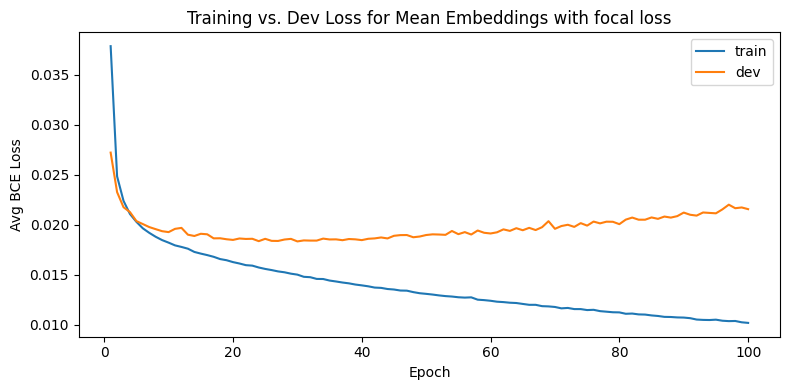

Exact-match accuracy : 0.5047
Hamming accuracy     : 0.9301
Jaccard (samples)    : 0.6388
Micro F1             : 0.7144
Macro F1             : 0.6343

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8860     0.7181
Cytoplasm                     0.8046     0.5666
Nucleus                       0.8363     0.6316
Extracellular                 0.9742     0.8742
Cell membrane                 0.9245     0.6576
Mitochondrion                 0.9570     0.6964
Plastid                       0.9946     0.9255
Endoplasmic reticulum         0.9408     0.5086
Lysosome/Vacuole              0.9539     0.3295
Golgi apparatus               0.9638     0.4981
Peroxisome                    0.9950     0.3853


In [16]:
# experiment 7: investigate focal loss - mean - 100 epochs
import torchvision

def focal_loss(logits, y_train):
    return torchvision.ops.sigmoid_focal_loss(logits, y_train, reduction='mean')
criterion_9 = focal_loss
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_9,  experiment_title="Mean Embeddings with focal loss", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [8]:
# prepare for experiment with ridge regression in the loss function - mean - 100 epochs

# this function is slightly different than the normal train model function because we 
# need to compute the dev loss with the normal criterion, not the regression criterion
# in order to track the actual performance of the model, not just the regression loss
def train_regressed_model(model, loader, criterion_reg, criterion, optimizer, x_dev_tensor, y_dev_tensor, num_epochs):
    train_loss_lst = []
    dev_loss_lst = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in loader:
            x_batch, y_batch = batch
            optimizer.zero_grad()
            logits = model(x_batch)
            loss_grad = criterion(logits, y_batch) + criterion_reg(model.model[0].weight, model.model[2].weight, model.model[4].weight, lambda_reg=0.0001)
            loss_grad.backward()
            optimizer.step()
            
            # get the actual loss without regression
            loss = criterion(logits, y_batch)
            train_loss += loss.item() * x_batch.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)

        # evaluate on dev set
        model.eval()
        with torch.no_grad():
            dev_logits = model(x_dev_tensor)
            dev_loss = criterion(dev_logits, y_dev_tensor)
            dev_loss_lst.append(dev_loss.item())
        
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Dev Loss: {dev_loss.item():.4f}")
    print("Training complete.")
    return train_loss_lst, dev_loss_lst

# need a new experiment function too to pass the parameters
def run_experiment_reg(x_train, y_train, train_loader, x_dev, y_dev, criterion_reg, criterion_wo_reg, experiment_title, num_epochs):
    model = MLP(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst, dev_loss_lst = train_regressed_model(model, train_loader, criterion_reg, criterion_wo_reg, optimizer, x_dev, y_dev, num_epochs)

    # graph the losses
    plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

Epoch 1/100, Train Loss: 0.3462, Dev Loss: 0.2620
Epoch 11/100, Train Loss: 0.1802, Dev Loss: 0.1895
Epoch 21/100, Train Loss: 0.1659, Dev Loss: 0.1818
Epoch 31/100, Train Loss: 0.1570, Dev Loss: 0.1805
Epoch 41/100, Train Loss: 0.1495, Dev Loss: 0.1803
Epoch 51/100, Train Loss: 0.1442, Dev Loss: 0.1755
Epoch 61/100, Train Loss: 0.1356, Dev Loss: 0.1881
Epoch 71/100, Train Loss: 0.1321, Dev Loss: 0.1794
Epoch 81/100, Train Loss: 0.1261, Dev Loss: 0.1780
Epoch 91/100, Train Loss: 0.1217, Dev Loss: 0.1809
Epoch 100/100, Train Loss: 0.1179, Dev Loss: 0.1793
Training complete.


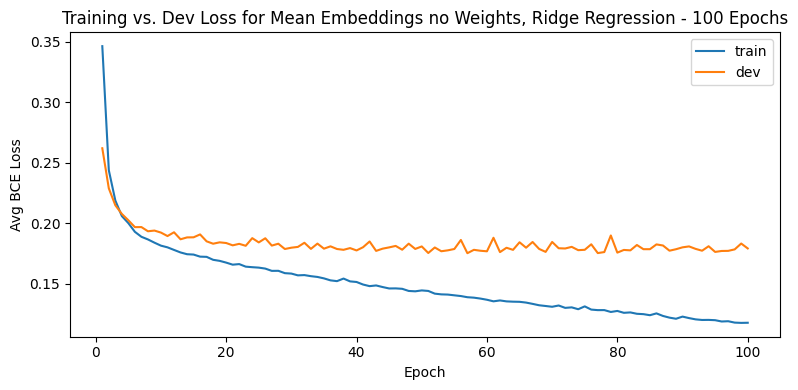

Exact-match accuracy : 0.5283
Hamming accuracy     : 0.9309
Jaccard (samples)    : 0.6870
Micro F1             : 0.7452
Macro F1             : 0.6410

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8874     0.7315
Cytoplasm                     0.8037     0.5700
Nucleus                       0.8535     0.6740
Extracellular                 0.9801     0.9047
Cell membrane                 0.9240     0.6728
Mitochondrion                 0.9607     0.7236
Plastid                       0.9869     0.8086
Endoplasmic reticulum         0.9371     0.5372
Lysosome/Vacuole              0.9530     0.2811
Golgi apparatus               0.9579     0.4377
Peroxisome                    0.9955     0.4314


In [19]:
# experiment 8 ridge resgression on mean - 100 epochs

def ridge_regression(w1, w2, w3, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2 + torch.linalg.matrix_norm(w3)**2)
    return y

criterion_reg = ridge_regression
criterion_wo_reg = nn.BCEWithLogitsLoss()
title = "Mean Embeddings no Weights, Ridge Regression - 100 Epochs"
regression_model_mean = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg, criterion_wo_reg, experiment_title=title, num_epochs=100)
compute_accuracy(regression_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/100, Train Loss: 4.2280, Dev Loss: 2.9110
Epoch 11/100, Train Loss: 1.5669, Dev Loss: 1.7059
Epoch 21/100, Train Loss: 1.2585, Dev Loss: 1.6708
Epoch 31/100, Train Loss: 1.0517, Dev Loss: 1.6542
Epoch 41/100, Train Loss: 0.9105, Dev Loss: 1.7199
Epoch 51/100, Train Loss: 0.7794, Dev Loss: 1.8100
Epoch 61/100, Train Loss: 0.7026, Dev Loss: 1.8393
Epoch 71/100, Train Loss: 0.6054, Dev Loss: 1.9803
Epoch 81/100, Train Loss: 0.5468, Dev Loss: 2.1385
Epoch 91/100, Train Loss: 0.4908, Dev Loss: 2.2101
Epoch 100/100, Train Loss: 0.4792, Dev Loss: 2.3943
Training complete.


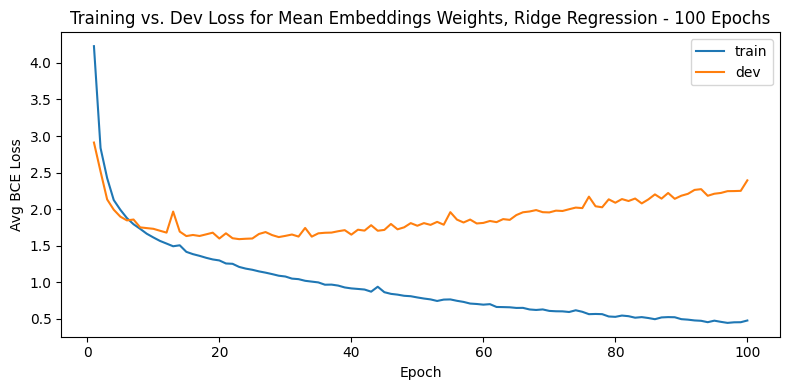

Exact-match accuracy : 0.5278
Hamming accuracy     : 0.9311
Jaccard (samples)    : 0.7023
Micro F1             : 0.7548
Macro F1             : 0.7066

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8833     0.7185
Cytoplasm                     0.8091     0.5861
Nucleus                       0.8408     0.6525
Extracellular                 0.9801     0.9063
Cell membrane                 0.9218     0.6811
Mitochondrion                 0.9557     0.7068
Plastid                       0.9928     0.9005
Endoplasmic reticulum         0.9426     0.5683
Lysosome/Vacuole              0.9579     0.4668
Golgi apparatus               0.9625     0.5178
Peroxisome                    0.9959     0.6072


In [24]:
# experiment 9 - ridge resgression on mean weighted - 100 epochs
def ridge_regression(w1, w2, w3, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2 + torch.linalg.matrix_norm(w3)**2)
    return y

criterion_reg_9 = ridge_regression
criterion_wo_reg_9 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression - 100 Epochs"
regression_model_mean_9 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_9, criterion_wo_reg_9, experiment_title=title, num_epochs=100)
compute_accuracy(regression_model_mean_9, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/200, Train Loss: 4.3119, Dev Loss: 2.9709
Epoch 11/200, Train Loss: 1.8119, Dev Loss: 1.8120
Epoch 21/200, Train Loss: 1.5244, Dev Loss: 1.7027
Epoch 31/200, Train Loss: 1.3613, Dev Loss: 1.6218
Epoch 41/200, Train Loss: 1.2381, Dev Loss: 1.5915
Epoch 51/200, Train Loss: 1.1480, Dev Loss: 1.5847
Epoch 61/200, Train Loss: 1.0657, Dev Loss: 1.5726
Epoch 71/200, Train Loss: 1.0026, Dev Loss: 1.6023
Epoch 81/200, Train Loss: 0.9507, Dev Loss: 1.6196
Epoch 91/200, Train Loss: 0.9053, Dev Loss: 1.6408
Epoch 101/200, Train Loss: 0.8566, Dev Loss: 1.6324
Epoch 111/200, Train Loss: 0.8317, Dev Loss: 1.6577
Epoch 121/200, Train Loss: 0.7982, Dev Loss: 1.6556
Epoch 131/200, Train Loss: 0.7659, Dev Loss: 1.6642
Epoch 141/200, Train Loss: 0.7441, Dev Loss: 1.7616
Epoch 151/200, Train Loss: 0.7161, Dev Loss: 1.7036
Epoch 161/200, Train Loss: 0.7022, Dev Loss: 1.7347
Epoch 171/200, Train Loss: 0.6832, Dev Loss: 1.7446
Epoch 181/200, Train Loss: 0.6615, Dev Loss: 1.7445
Epoch 191/200, Train Lo

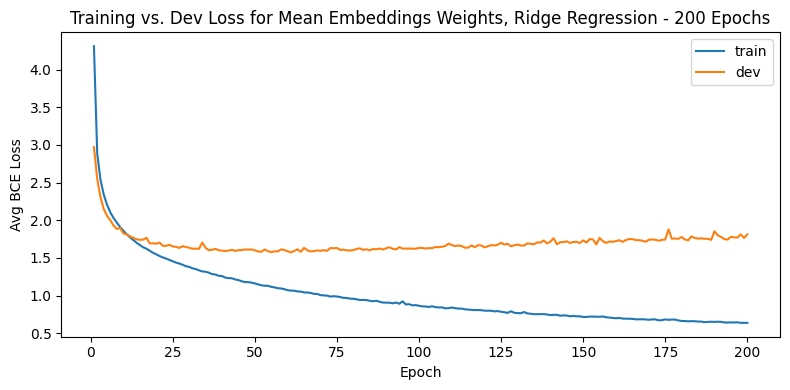

Exact-match accuracy : 0.5260
Hamming accuracy     : 0.9343
Jaccard (samples)    : 0.6990
Micro F1             : 0.7581
Macro F1             : 0.7014

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8969     0.7474
Cytoplasm                     0.8227     0.6268
Nucleus                       0.8498     0.6593
Extracellular                 0.9751     0.8816
Cell membrane                 0.9258     0.6664
Mitochondrion                 0.9625     0.7392
Plastid                       0.9928     0.8993
Endoplasmic reticulum         0.9435     0.5546
Lysosome/Vacuole              0.9548     0.4293
Golgi apparatus               0.9607     0.5594
Peroxisome                    0.9932     0.5640


In [ ]:
# experiment 10 - ridge resgression on mean weighted - 200 epochs

def ridge_regression(w1, w2, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_10 = ridge_regression
criterion_wo_reg_10 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression - 200 Epochs"
regression_model_mean_10 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_10, criterion_wo_reg_10, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_10, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/200, Train Loss: 4.3138, Dev Loss: 2.8952
Epoch 11/200, Train Loss: 1.7677, Dev Loss: 1.7705
Epoch 21/200, Train Loss: 1.4938, Dev Loss: 1.6482
Epoch 31/200, Train Loss: 1.3409, Dev Loss: 1.6001
Epoch 41/200, Train Loss: 1.2110, Dev Loss: 1.5924
Epoch 51/200, Train Loss: 1.1133, Dev Loss: 1.5952
Epoch 61/200, Train Loss: 1.0359, Dev Loss: 1.6046
Epoch 71/200, Train Loss: 0.9705, Dev Loss: 1.6168
Epoch 81/200, Train Loss: 0.9227, Dev Loss: 1.6199
Epoch 91/200, Train Loss: 0.8717, Dev Loss: 1.6532
Epoch 101/200, Train Loss: 0.8292, Dev Loss: 1.6409
Epoch 111/200, Train Loss: 0.8063, Dev Loss: 1.6919
Epoch 121/200, Train Loss: 0.7663, Dev Loss: 1.6973
Epoch 131/200, Train Loss: 0.7352, Dev Loss: 1.7291
Epoch 141/200, Train Loss: 0.7157, Dev Loss: 1.7013
Epoch 151/200, Train Loss: 0.6955, Dev Loss: 1.7354
Epoch 161/200, Train Loss: 0.6734, Dev Loss: 1.7833
Epoch 171/200, Train Loss: 0.6575, Dev Loss: 1.7809
Epoch 181/200, Train Loss: 0.6414, Dev Loss: 1.7755
Epoch 191/200, Train Lo

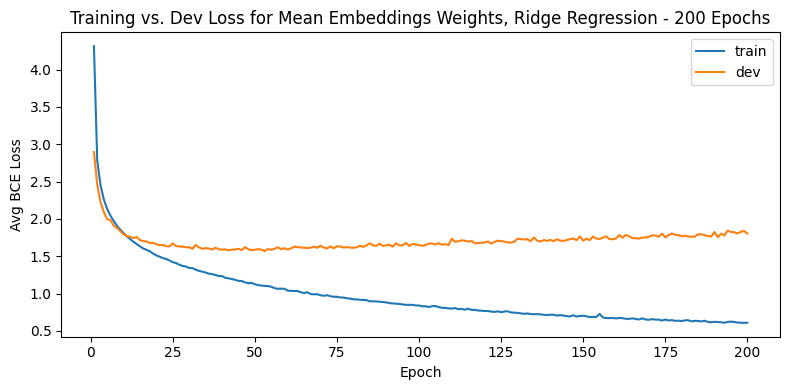

Exact-match accuracy : 0.5305
Hamming accuracy     : 0.9329
Jaccard (samples)    : 0.7028
Micro F1             : 0.7578
Macro F1             : 0.7034

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8878     0.7228
Cytoplasm                     0.8150     0.6169
Nucleus                       0.8471     0.6584
Extracellular                 0.9756     0.8846
Cell membrane                 0.9240     0.6833
Mitochondrion                 0.9643     0.7472
Plastid                       0.9946     0.9252
Endoplasmic reticulum         0.9412     0.5473
Lysosome/Vacuole              0.9557     0.4288
Golgi apparatus               0.9616     0.5470
Peroxisome                    0.9955     0.5455


In [ ]:
# experiment 11 - ridge resgression on mean weighted - 200 epochs, lambda = 0.01

def ridge_regression(w1, w2, lambda_reg=0.01):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_11 = ridge_regression
criterion_wo_reg_11 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.01 - 200 Epochs"
regression_model_mean_11 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_11, criterion_wo_reg_11, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_11, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/100, Train Loss: 4.3301, Dev Loss: 3.0173
Epoch 11/100, Train Loss: 1.7932, Dev Loss: 1.7902
Epoch 21/100, Train Loss: 1.5157, Dev Loss: 1.6591
Epoch 31/100, Train Loss: 1.3406, Dev Loss: 1.6350
Epoch 41/100, Train Loss: 1.2187, Dev Loss: 1.5992
Epoch 51/100, Train Loss: 1.1144, Dev Loss: 1.6176
Epoch 61/100, Train Loss: 1.0315, Dev Loss: 1.6042
Epoch 71/100, Train Loss: 0.9599, Dev Loss: 1.6244
Epoch 81/100, Train Loss: 0.9158, Dev Loss: 1.6209
Epoch 91/100, Train Loss: 0.8540, Dev Loss: 1.6422
Epoch 100/100, Train Loss: 0.8248, Dev Loss: 1.6702
Training complete.


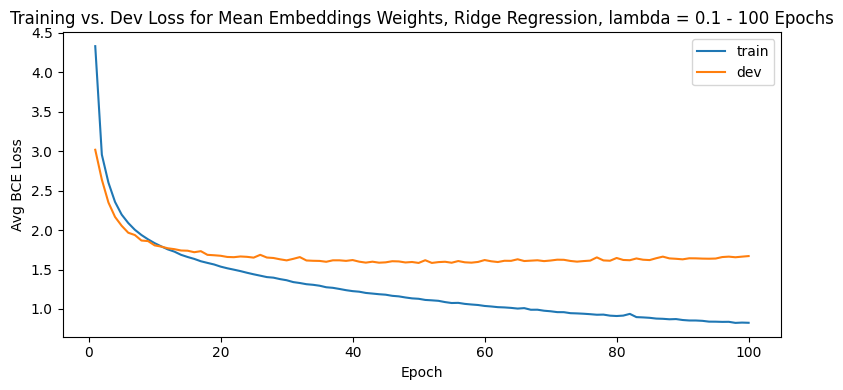

Exact-match accuracy : 0.5301
Hamming accuracy     : 0.9323
Jaccard (samples)    : 0.6984
Micro F1             : 0.7515
Macro F1             : 0.6964

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8860     0.7191
Cytoplasm                     0.8223     0.6299
Nucleus                       0.8480     0.6548
Extracellular                 0.9783     0.8974
Cell membrane                 0.9236     0.6590
Mitochondrion                 0.9634     0.7456
Plastid                       0.9905     0.8656
Endoplasmic reticulum         0.9398     0.5434
Lysosome/Vacuole              0.9448     0.4215
Golgi apparatus               0.9634     0.5580
Peroxisome                    0.9950     0.5197


In [35]:
# experiment 12 - ridge resgression on mean weighted - 100 epochs, lambda = 0.1

def ridge_regression(w1, w2, lambda_reg=0.1):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_12 = ridge_regression
criterion_wo_reg_12 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.1 - 100 Epochs"
regression_model_mean_12 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_12, criterion_wo_reg_12, experiment_title=title, num_epochs=100)
compute_accuracy(regression_model_mean_12, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/200, Train Loss: 4.4426, Dev Loss: 2.9074
Epoch 11/200, Train Loss: 1.7766, Dev Loss: 1.7641
Epoch 21/200, Train Loss: 1.5177, Dev Loss: 1.6641
Epoch 31/200, Train Loss: 1.3552, Dev Loss: 1.6161
Epoch 41/200, Train Loss: 1.2293, Dev Loss: 1.5869
Epoch 51/200, Train Loss: 1.1356, Dev Loss: 1.6180
Epoch 61/200, Train Loss: 1.0520, Dev Loss: 1.5753
Epoch 71/200, Train Loss: 0.9826, Dev Loss: 1.5948
Epoch 81/200, Train Loss: 0.9381, Dev Loss: 1.6530
Epoch 91/200, Train Loss: 0.8853, Dev Loss: 1.6522
Epoch 101/200, Train Loss: 0.8517, Dev Loss: 1.6623
Epoch 111/200, Train Loss: 0.8087, Dev Loss: 1.6718
Epoch 121/200, Train Loss: 0.7875, Dev Loss: 1.6727
Epoch 131/200, Train Loss: 0.7460, Dev Loss: 1.7177
Epoch 141/200, Train Loss: 0.7196, Dev Loss: 1.7261
Epoch 151/200, Train Loss: 0.6978, Dev Loss: 1.7206
Epoch 161/200, Train Loss: 0.6713, Dev Loss: 1.7695
Epoch 171/200, Train Loss: 0.6564, Dev Loss: 1.7469
Epoch 181/200, Train Loss: 0.6428, Dev Loss: 1.7678
Epoch 191/200, Train Lo

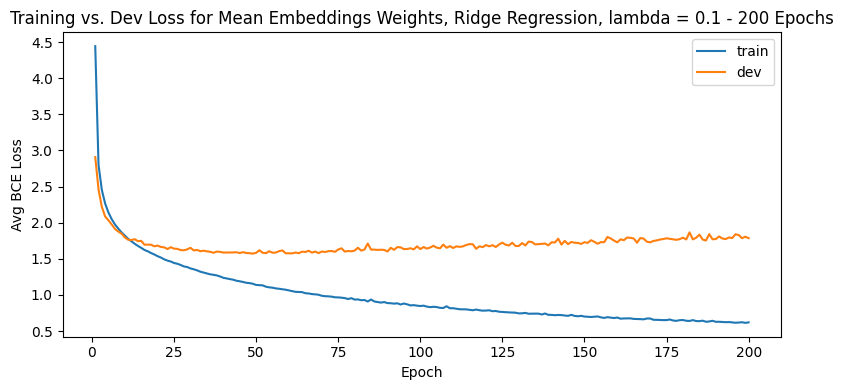

Exact-match accuracy : 0.5287
Hamming accuracy     : 0.9323
Jaccard (samples)    : 0.6948
Micro F1             : 0.7521
Macro F1             : 0.6883

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8851     0.7187
Cytoplasm                     0.8123     0.5898
Nucleus                       0.8399     0.6485
Extracellular                 0.9769     0.8899
Cell membrane                 0.9281     0.6921
Mitochondrion                 0.9620     0.7338
Plastid                       0.9923     0.8923
Endoplasmic reticulum         0.9444     0.5563
Lysosome/Vacuole              0.9557     0.4712
Golgi apparatus               0.9643     0.5590
Peroxisome                    0.9941     0.3820


In [34]:
# experiment 13 - ridge resgression on mean weighted - 200 epochs, lambda = 0.1

def ridge_regression(w1, w2, lambda_reg=0.5):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_13 = ridge_regression
criterion_wo_reg_13 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.1 - 200 Epochs"
regression_model_mean_13 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_13, criterion_wo_reg_13, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_13, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [11]:
import loc_utils as lu

# experiment 14: control with no reweighting on mean - 100 epochs - MCC optimization
criterion_1 = nn.BCEWithLogitsLoss()
reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
cutoffs = lu.compute_optimized_cutoffs(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
lu.compute_accuracy_with_special_cutoffs(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations, cutoffs)

Epoch 1/100, Train Loss: 0.3562, Dev Loss: 0.2696
Epoch 11/100, Train Loss: 0.1704, Dev Loss: 0.1840
Epoch 21/100, Train Loss: 0.1474, Dev Loss: 0.1776
Epoch 31/100, Train Loss: 0.1281, Dev Loss: 0.1766
Epoch 41/100, Train Loss: 0.1117, Dev Loss: 0.1813


KeyboardInterrupt: 

Epoch 1/100, Train Loss: 0.3668, Dev Loss: 0.2831
Epoch 11/100, Train Loss: 0.1830, Dev Loss: 0.1906
Epoch 21/100, Train Loss: 0.1682, Dev Loss: 0.1862
Epoch 31/100, Train Loss: 0.1584, Dev Loss: 0.1784
Epoch 41/100, Train Loss: 0.1507, Dev Loss: 0.1789
Epoch 51/100, Train Loss: 0.1455, Dev Loss: 0.1801
Epoch 61/100, Train Loss: 0.1380, Dev Loss: 0.1793
Epoch 71/100, Train Loss: 0.1319, Dev Loss: 0.1769
Epoch 81/100, Train Loss: 0.1283, Dev Loss: 0.1781
Epoch 91/100, Train Loss: 0.1219, Dev Loss: 0.1863
Epoch 100/100, Train Loss: 0.1182, Dev Loss: 0.1827
Training complete.


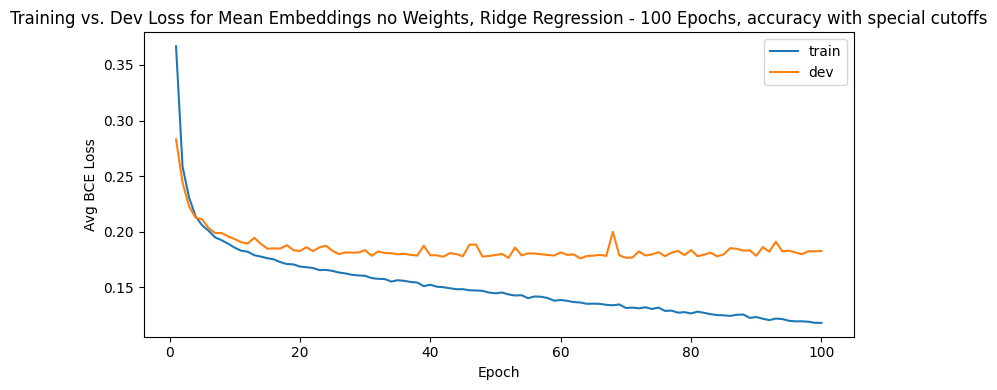

Membrane                 , Best Cutoff:     0.5000, Best MCC:     0.7371
Cytoplasm                , Best Cutoff:     0.2700, Best MCC:     0.6411
Nucleus                  , Best Cutoff:     0.6100, Best MCC:     0.6712
Extracellular            , Best Cutoff:     0.5600, Best MCC:     0.8994
Cell membrane            , Best Cutoff:     0.4200, Best MCC:     0.6903
Mitochondrion            , Best Cutoff:     0.6700, Best MCC:     0.7545
Plastid                  , Best Cutoff:     0.2800, Best MCC:     0.8872
Endoplasmic reticulum    , Best Cutoff:     0.5800, Best MCC:     0.5591
Lysosome/Vacuole         , Best Cutoff:     0.1700, Best MCC:     0.3910
Golgi apparatus          , Best Cutoff:     0.3100, Best MCC:     0.5300
Peroxisome               , Best Cutoff:     0.1300, Best MCC:     0.4695
Exact-match accuracy : 0.5369
Hamming accuracy     : 0.9342
Jaccard (samples)    : 0.7141
Micro F1             : 0.7658
Macro F1             : 0.6922

Per-class metrics:
Location                   

In [12]:
# experiment 15 ridge resgression on mean - 100 epochs
import loc_utils as lu 

def ridge_regression(w1, w2, w3, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2 + torch.linalg.matrix_norm(w3)**2)
    return y

criterion_reg = ridge_regression
criterion_wo_reg = nn.BCEWithLogitsLoss()
title = "Mean Embeddings no Weights, Ridge Regression - 100 Epochs, accuracy with special cutoffs"
regression_model_mean = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg, criterion_wo_reg, experiment_title=title, num_epochs=100)
cutoffs = lu.compute_optimized_cutoffs(regression_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)
lu.compute_accuracy_with_special_cutoffs(regression_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations, cutoffs)